# 07 Visualizations for Report

This notebook generates visualizations of the most influential features and other supporting plots for the final narrative.

In [1]:
# Author: Jessica
# Loading saved outputs so this notebook can create final charts independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_results = pd.read_csv("shared_data/model_results_summary.csv")
importance = pd.read_csv("shared_data/feature_importance.csv")

print(model_results)
importance.head()

                          Model  Accuracy  Precision_Inspection  \
0           Logistic Regression      0.80                  0.58   
1  Balanced Logistic Regression      0.74                  0.44   
2                 Random Forest      0.84                  0.67   

   Recall_Inspection  F1_Inspection  
0               0.24           0.34  
1               0.69           0.54  
2               0.50           0.58  


,feature,coefficient
0,prior_inspection_count,0.429642
1,critical_violations,0.364306
2,total_violations,0.164942
3,historical_avg_score,0.031999
4,inspection_month,0.027930


## Scope

This notebook contains the final charts used to communicate model insights in the report and presentation.

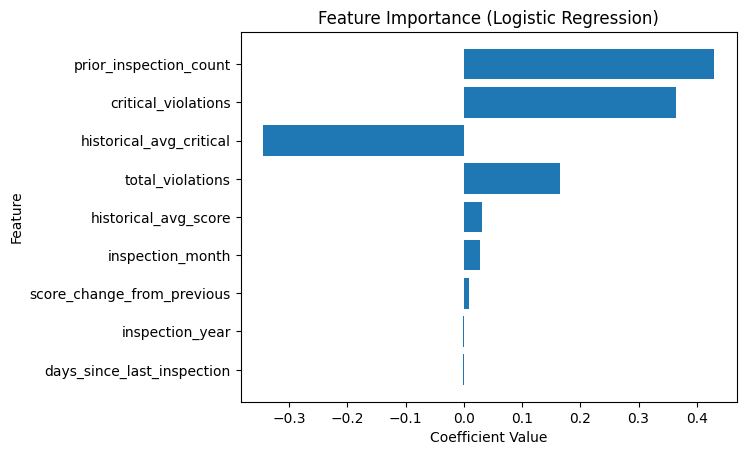

In [2]:
# Author: Jessica
# Visualizing feature importance from logistic regression coefficients

import matplotlib.pyplot as plt

importance_sorted = importance.sort_values(by='coefficient', key=abs, ascending=True)

plt.figure()
plt.barh(importance_sorted['feature'], importance_sorted['coefficient'])
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

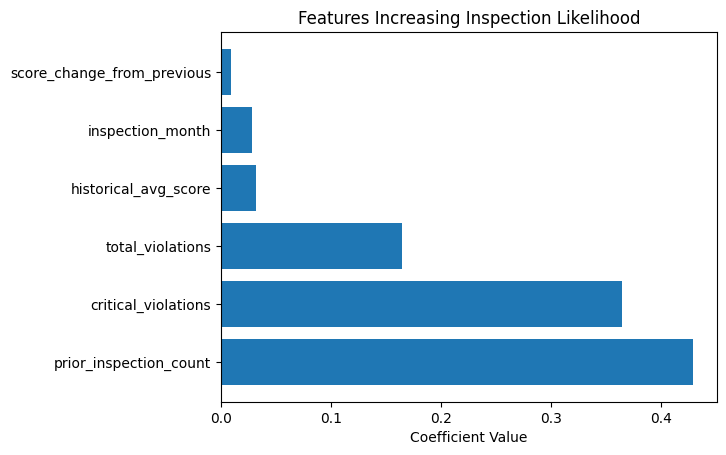

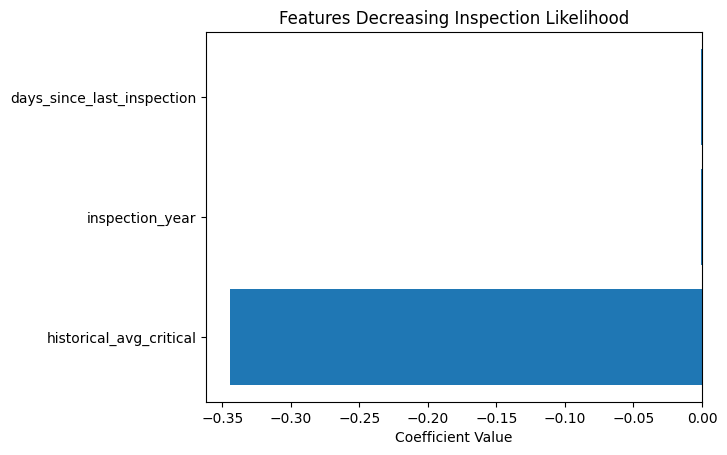

In [3]:
# Author: Jessica
# Separating features that increase vs decrease inspection likelihood

positive_features = importance[importance['coefficient'] > 0].sort_values(by='coefficient', ascending=False)
negative_features = importance[importance['coefficient'] < 0].sort_values(by='coefficient')

plt.figure()
plt.barh(positive_features['feature'], positive_features['coefficient'])
plt.title('Features Increasing Inspection Likelihood')
plt.xlabel('Coefficient Value')
plt.show()

plt.figure()
plt.barh(negative_features['feature'], negative_features['coefficient'])
plt.title('Features Decreasing Inspection Likelihood')
plt.xlabel('Coefficient Value')
plt.show()

Long-term trends matter less than recent activity in determining inspections.

## Model Comparison Visuals

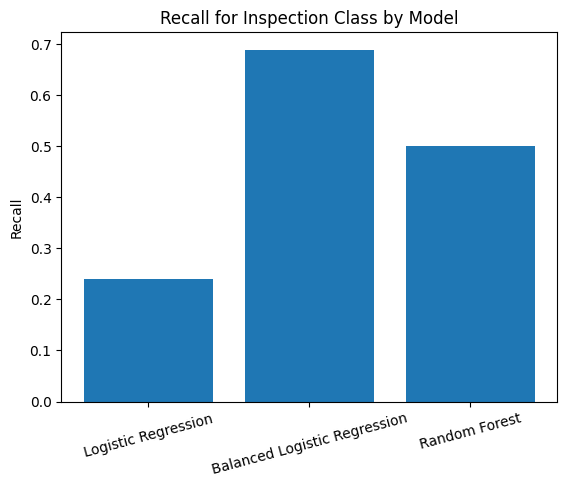

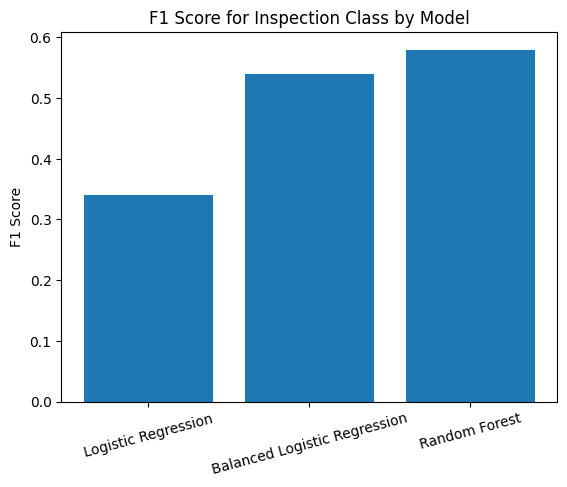

In [4]:
# Author: Jessica
# Comparing models using recall and F1 for the inspection class

plt.figure()
plt.bar(model_results['Model'], model_results['Recall_Inspection'])
plt.title('Recall for Inspection Class by Model')
plt.ylabel('Recall')
plt.xticks(rotation=15)
plt.show()

plt.figure()
plt.bar(model_results['Model'], model_results['F1_Inspection'])
plt.title('F1 Score for Inspection Class by Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=15)
plt.show()

In [ ]:
#Inspection
# Author: Joel Barnes
# Testing accuracy and loss interpretation for saved model predictions

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

predictions_df = pd.read_csv("shared_data/model_predictions.csv")
models = {
    'Logistic Regression': 'logistic_pred',
    'Balanced Logistic Regression': 'balanced_logistic_pred',
    'Random Forest': 'random_forest_pred'
}

accuracy_scores = {}
test_loss = {}
for model_name, pred_col in models.items():
    y_true = predictions_df['y_test']
    y_pred = predictions_df[pred_col]
    accuracy_scores[model_name] = accuracy_score(y_true, y_pred)
    test_loss[model_name] = 1.0 - accuracy_scores[model_name]

accuracy_df = pd.DataFrame({
    'Model': list(accuracy_scores.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'Test_Loss': list(test_loss.values())
})

print(accuracy_df)

plt.figure(figsize=(8, 5))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'], color=['#4c72b0', '#55a868', '#c44e52'])
plt.ylim(0, 1)
plt.title('Test Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(accuracy_df['Model'], accuracy_df['Test_Loss'], color=['#8172b2', '#ccb974', '#64b5cd'])
plt.ylim(0, 1)
plt.title('Testing Loss by Model (Error Rate)')
plt.ylabel('Test Loss (1 - Accuracy)')
plt.xticks(rotation=15)
plt.show()

for model_name, pred_col in models.items():
    print(f"\n=== {model_name} Classification Report ===")
    print(classification_report(predictions_df['y_test'], predictions_df[pred_col], digits=3))

In [ ]:
# Author: Joel Barnes
# Explainability analysis using model feature coefficients

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.read_csv("shared_data/feature_importance.csv")
importance['abs_coef'] = importance['coefficient'].abs()

importance_sorted = importance.sort_values(by='abs_coef', ascending=False)
top_features = importance_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['feature'][::-1],
    top_features['coefficient'][::-1],
    color=['#4c72b0' if c > 0 else '#c44e52' for c in top_features['coefficient'][::-1]]
)
plt.title('Top 10 Features by Coefficient Magnitude')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

positive_features = importance[importance['coefficient'] > 0].sort_values(by='coefficient', ascending=False).head(10)
negative_features = importance[importance['coefficient'] < 0].sort_values(by='coefficient').head(10)

plt.figure(figsize=(10, 4))
plt.barh(positive_features['feature'][::-1], positive_features['coefficient'][::-1], color='#55a868')
plt.title('Top Positive Drivers of Inspection Likelihood')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.barh(negative_features['feature'], negative_features['coefficient'], color='#c44e52')
plt.title('Top Negative Drivers of Inspection Likelihood')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top positive predictors:')
print(positive_features[['feature', 'coefficient']].to_string(index=False))
print('\nTop negative predictors:')
print(negative_features[['feature', 'coefficient']].to_string(index=False))

In [ ]:
# Author: Joel Barnes
# Error diagnostics for saved model predictions

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

predictions_df = pd.read_csv("shared_data/model_predictions.csv")
models = {
    'Logistic Regression': 'logistic_pred',
    'Balanced Logistic Regression': 'balanced_logistic_pred',
    'Random Forest': 'random_forest_pred'
}

diag_rows = []
for model_name, pred_col in models.items():
    y_true = predictions_df['y_test']
    y_pred = predictions_df[pred_col]
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Inspection', 'Inspection'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    accuracy = accuracy_score(y_true, y_pred)
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) else 0.0
    diag_rows.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'False Positives': fp,
        'False Negatives': fn,
        'False Positive Rate': false_positive_rate,
        'False Negative Rate': false_negative_rate,
        'Total Error Rate': 1.0 - accuracy
    })

    print(f'=== {model_name} Error Diagnostics ===')
    print(f'True negatives: {tn}, false positives: {fp}')
    print(f'False negatives: {fn}, true positives: {tp}')
    print(f'False positive rate: {false_positive_rate:.3f}')
    print(f'False negative rate: {false_negative_rate:.3f}')
    print(classification_report(y_true, y_pred, target_names=['No Inspection', 'Inspection'], digits=3))
    print('-' * 60)

error_diag = pd.DataFrame(diag_rows)
print(error_diag)

plt.figure(figsize=(10, 5))
plt.plot(error_diag['Model'], error_diag['False Positive Rate'], marker='o', label='False Positive Rate')
plt.plot(error_diag['Model'], error_diag['False Negative Rate'], marker='o', label='False Negative Rate')
plt.ylim(0, 1)
plt.title('Model Error Diagnostics')
plt.xlabel('Model')
plt.ylabel('Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()